In [6]:
import pandas as pd

In [11]:
df=pd.DataFrame(pd.read_csv("./Datasets/employee.csv"))

In [12]:
df

,job_role,education,monthly_income,marital_status,interaction
0,sales executive,marketing,10000,married,1
1,manager,medical,500000,single,0
2,research scientist,life science,43217,divorced,0
3,laboratory technician,life science,1000,single,1
4,sales executive,marketing,100000,married,0
5,manager,life science,50000,married,0


In [15]:
# if person is in sales executive, education is life science, monthly income is 1000, and marital status is single how the change of interaction is 1 or 0 from KNN model

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [16]:
df.head()

,job_role,education,monthly_income,marital_status,interaction
0,sales executive,marketing,10000,married,1
1,manager,medical,500000,single,0
2,research scientist,life science,43217,divorced,0
3,laboratory technician,life science,1000,single,1
4,sales executive,marketing,100000,married,0


In [17]:
# Features and target
X = df.drop('interaction', axis=1)
y = df['interaction']

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN Model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Results
print("Prediction:", y_pred)
print("Actual:", y_test.values)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Only print report if test set has enough samples
if len(y_test.unique()) > 1:
    print(classification_report(y_test, y_pred))

Prediction: [0 0]
Actual: [1 0]
Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



c:\EXL\py_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\EXL\py_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\EXL\py_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [21]:
# tesing the model with new data
new_data = pd.DataFrame({
    'job_role': ['sales executive'],
    'education': ['life science'],
    'monthly_income': [4000],
    'maritail_status':'single'
})

new_data = pd.get_dummies(new_data, drop_first=True)
# ensure new_data has same columns as training data (add missing dummies with 0)
new_data = new_data.reindex(columns=X.columns, fill_value=0)
new_data = scaler.transform(new_data)
new_pred = knn.predict(new_data)
print("New Prediction:", new_pred)

New Prediction: [0]


In [33]:
loan=pd.DataFrame(pd.read_csv("./Datasets/loan.csv"))
# taking out age,amount,status
loan["Age"] = np.random.randint(20, 61, size=len(loan))

In [44]:
# taking out age,amount,status
loan = loan[['Age', 'LoanAmount', 'Loan_Status']]
loan['LoanAmount'] = loan['LoanAmount'].fillna(loan['LoanAmount'].median())

In [45]:
loan

,Age,LoanAmount,Loan_Status
0,45,128.0,Y
1,56,128.0,N
2,50,66.0,Y
3,45,120.0,Y
4,51,141.0,Y
...,...,...,...
609,44,71.0,Y
610,25,40.0,Y
611,57,253.0,Y
612,45,187.0,Y


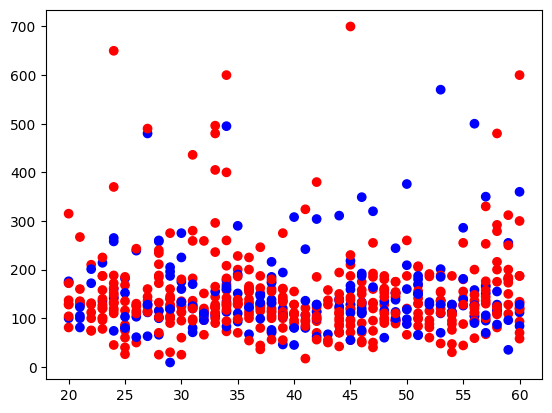

In [57]:
import matplotlib.pyplot as plt
plt.scatter(loan['Age'], loan['LoanAmount'], c=loan['Loan_Status'].map({'Y': 1, 'N': 0}), cmap='bwr')

In [54]:
# Euclidean distance function
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

new_point = np.array([30, 50000])  # Age=30, LoanAmount=50000

distances = []

for i in range(len(loan)):
    point = loan.iloc[i][['Age', 'LoanAmount']].values.astype(float)

    distance = euclidean_distance(point, new_point)

    distances.append((distance, loan.iloc[i]['Loan_Status']))

# Convert to NumPy array (optional)
# distances = np.array(distances, dtype=object)

print(distances)


[(np.float64(49872.00225577473), 'Y'), (np.float64(49872.006777349554), 'N'), (np.float64(49934.00400528682), 'Y'), (np.float64(49880.00225541294), 'Y'), (np.float64(49859.004422471175), 'Y'), (np.float64(49733.00081434861), 'Y'), (np.float64(49905.00361687192), 'Y'), (np.float64(49842.00325027075), 'N'), (np.float64(49832.00731457644), 'Y'), (np.float64(49651.00257799433), 'N'), (np.float64(49930.000640897255), 'Y'), (np.float64(49891.00842837314), 'Y'), (np.float64(49800.008443774386), 'Y'), (np.float64(49886.002565850074), 'N'), (np.float64(49983.00121041152), 'Y'), (np.float64(49875.00049122807), 'Y'), (np.float64(49900.00036072144), 'Y'), (np.float64(49924.00064097428), 'N'), (np.float64(49867.0048529085), 'N'), (np.float64(49885.00785807295), 'Y'), (np.float64(49896.000040083374), 'N'), (np.float64(49685.00100633993), 'Y'), (np.float64(49884.00785823048), 'N'), (np.float64(49888.000090202055), 'N'), (np.float64(49849.00731208195), 'N'), (np.float64(49809.00485855946), 'Y'), (np.f

In [55]:
# 3 nearest neighbors points values to the new point
distances.sort()  
nearest_neighbors = distances[:3]
print("3 Nearest Neighbors:", nearest_neighbors)

# Extract Age and LoanAmount values from nearest neighbors
for distance, status in nearest_neighbors:
    # Find the index in the loan dataframe where this distance matches
    for idx in range(len(loan)):
        point = loan.iloc[idx][['Age', 'LoanAmount']].values.astype(float)
        calc_distance = euclidean_distance(point, new_point)
        if abs(calc_distance - distance) < 0.01:  # Account for floating point precision
            age = loan.iloc[idx]['Age']
            loan_amount = loan.iloc[idx]['LoanAmount']
            print(f"Distance: {distance:.2f}, Age: {age}, LoanAmount: {loan_amount}, Status: {status}")
            break


3 Nearest Neighbors: [(np.float64(49300.00228194721), 'Y'), (np.float64(49350.00036474164), 'Y'), (np.float64(49400.00016194332), 'Y')]
Distance: 49300.00, Age: 45, LoanAmount: 700.0, Status: Y
Distance: 49350.00, Age: 24, LoanAmount: 650.0, Status: Y
Distance: 49400.00, Age: 60, LoanAmount: 600.0, Status: Y
